### Exponential the Data and Holt-Winters
#### Customer Compliant Reps

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\manoj.c\Documents\PANDAS_PROJECT\Pandas-Project-6\Datasets\weekly_customer_complaints.csv", index_col='week' , parse_dates=True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   complaints               261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


In [4]:
#Data Pre-processing
df['complaints'] = df['complaints'].str.replace(',','')
df['complaints'] = df['complaints'].astype(float)

In [5]:
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750.0,37.26%,1,0,0
2018-01-08,1701.0,35.38%,0,0,0
2018-01-15,1711.0,36.22%,1,0,0
2018-01-22,1443.0,38.33%,1,0,0
2018-01-29,1397.0,36.34%,0,0,0


In [6]:
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq=None)

In [7]:
# freq=None : I can't guarantee these dates follow a regular pattern.
# df.asfreq("W")
# the above won't work because "W" implies that the week starts on a 'SUNDAY'
df = df.asfreq("W-Mon")
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

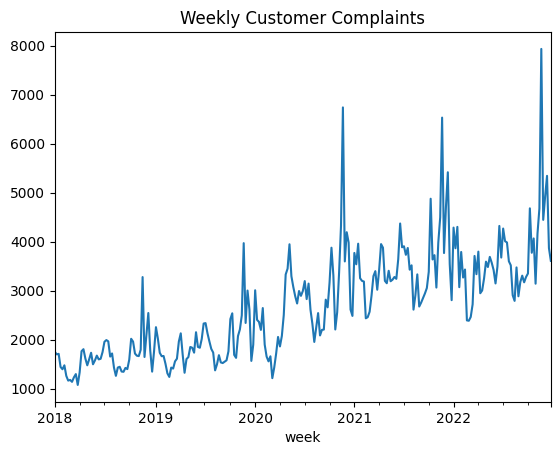

In [8]:
# Exploratory Data Analysis
df['complaints'].plot(title="Weekly Customer Complaints")
plt.show()

In [9]:
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf , plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [10]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Weekday'] = df.index.day_name()
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event,Year,Month,Day,Weekday
week,,,,,,,,,
2018-01-01,1750.0,37.26%,1,0,0,2018,1,1,Monday
2018-01-08,1701.0,35.38%,0,0,0,2018,1,8,Monday
2018-01-15,1711.0,36.22%,1,0,0,2018,1,15,Monday
2018-01-22,1443.0,38.33%,1,0,0,2018,1,22,Monday
2018-01-29,1397.0,36.34%,0,0,0,2018,1,29,Monday


C:\Users\manoj.c\AppData\Local\Temp\ipykernel_11848\1760179425.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['complaints'].resample("M").mean(),ylabel='Complaints')


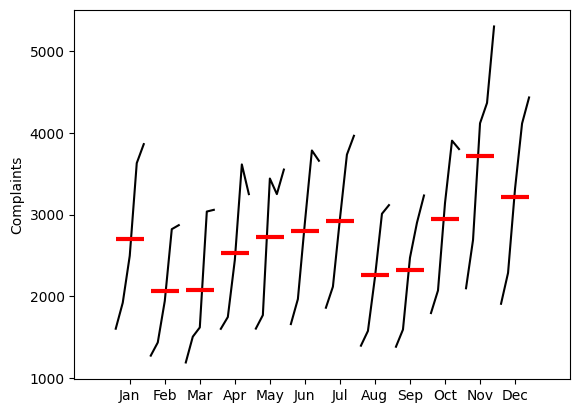

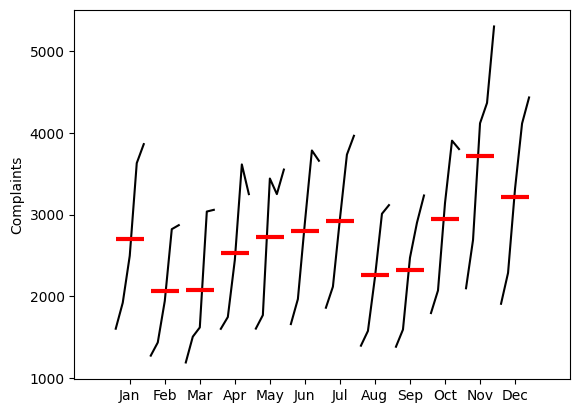

In [11]:
month_plot(df['complaints'].resample("M").mean(),ylabel='Complaints')

C:\Users\manoj.c\AppData\Local\Temp\ipykernel_11848\3463949770.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['complaints'].resample('Q').mean(), ylabel="Complaints")


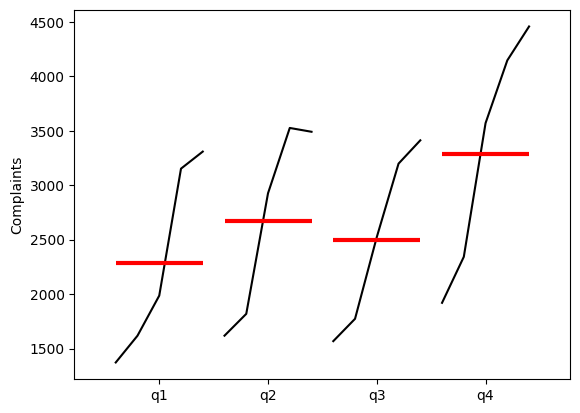

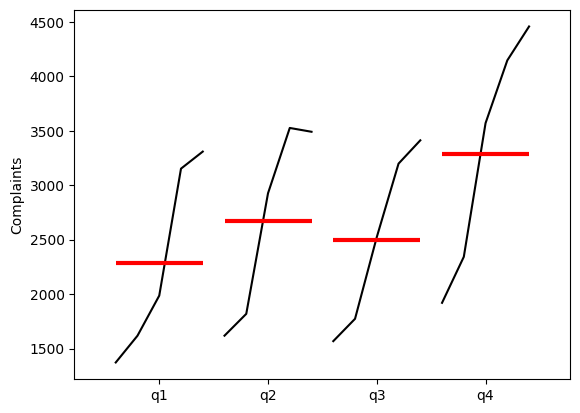

In [12]:
quarter_plot(df['complaints'].resample('Q').mean(), ylabel="Complaints")

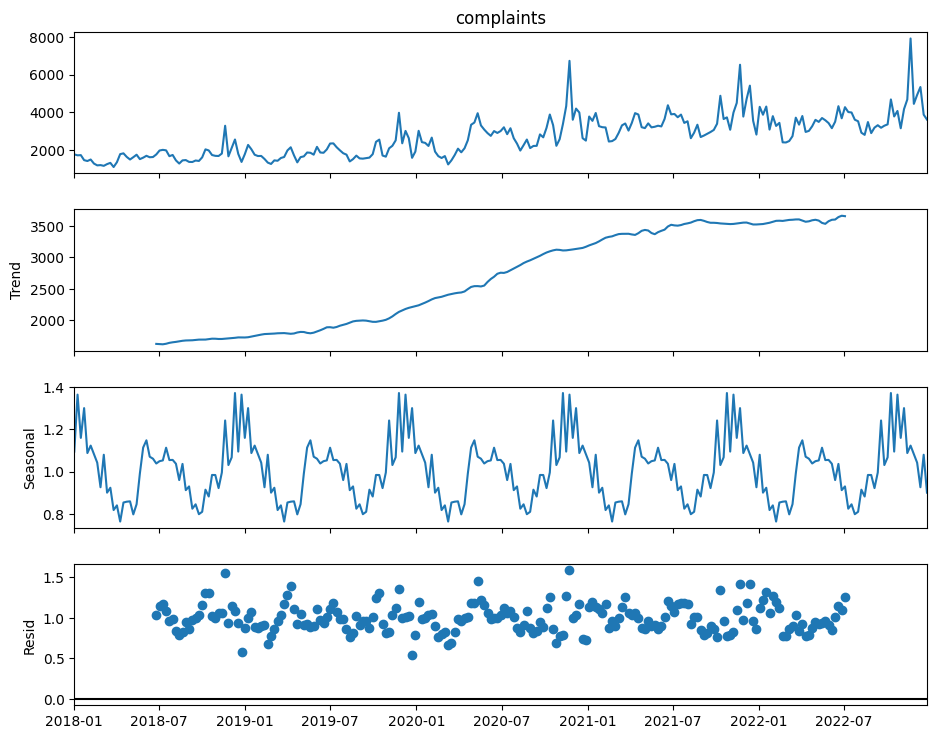

In [13]:
decompose = seasonal_decompose(df['complaints'],model='mul',period=50)
fig = decompose.plot()
fig.set_size_inches(10,8)

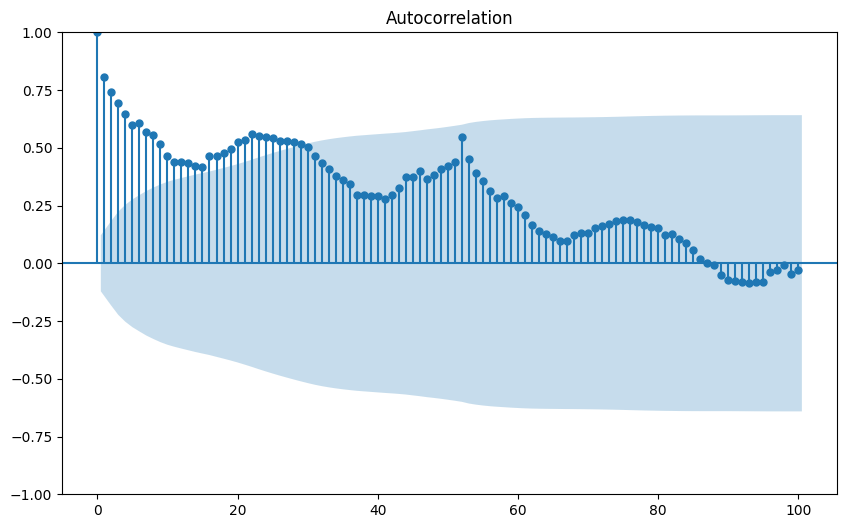

In [14]:
fig , ax = plt.subplots(figsize = (10,6))
plot_acf(df['complaints'],lags=100, ax=ax)
plt.show()

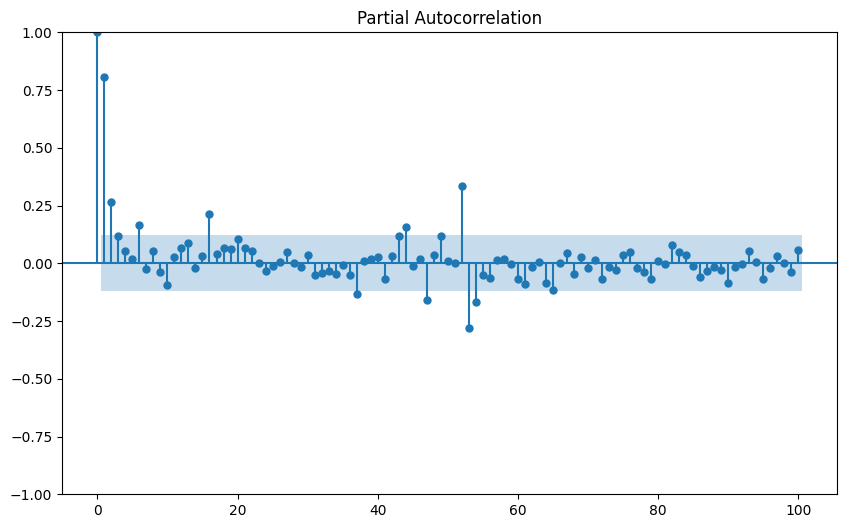

In [15]:
fig,ax = plt.subplots(figsize=(10,6))
plot_pacf(df['complaints'],lags=100, ax=ax)
plt.show()

#### Training and Test
#Goal: To predict the next quarter (13 weeks)

In [16]:
# Training and test split
train, test = df.iloc[:-13,0],df.iloc[-13:,0]

In [17]:
train

week
2018-01-01    1750.0
2018-01-08    1701.0
2018-01-15    1711.0
2018-01-22    1443.0
2018-01-29    1397.0
               ...  
2022-08-29    2885.0
2022-09-05    3177.0
2022-09-12    3306.0
2022-09-19    3170.0
2022-09-26    3279.0
Freq: W-MON, Name: complaints, Length: 248, dtype: float64

In [18]:
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

In [19]:
test

week
2022-10-03    3350.0
2022-10-10    4679.0
2022-10-17    3773.0
2022-10-24    4065.0
2022-10-31    3142.0
2022-11-07    4164.0
2022-11-14    4677.0
2022-11-21    7931.0
2022-11-28    4444.0
2022-12-05    4920.0
2022-12-12    5342.0
2022-12-19    3868.0
2022-12-26    3607.0
Freq: W-MON, Name: complaints, dtype: float64

#### Simple Exponential Smoothing

In [20]:
# Simple Exponential Smoothing Model and Prediction
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model_simple  = SimpleExpSmoothing(train).fit()
model_simple.forecast(len(test))

2022-10-03    3236.663473
2022-10-10    3236.663473
2022-10-17    3236.663473
2022-10-24    3236.663473
2022-10-31    3236.663473
2022-11-07    3236.663473
2022-11-14    3236.663473
2022-11-21    3236.663473
2022-11-28    3236.663473
2022-12-05    3236.663473
2022-12-12    3236.663473
2022-12-19    3236.663473
2022-12-26    3236.663473
Freq: W-MON, dtype: float64

In [21]:
prediction_simple = model_simple.forecast(len(test))

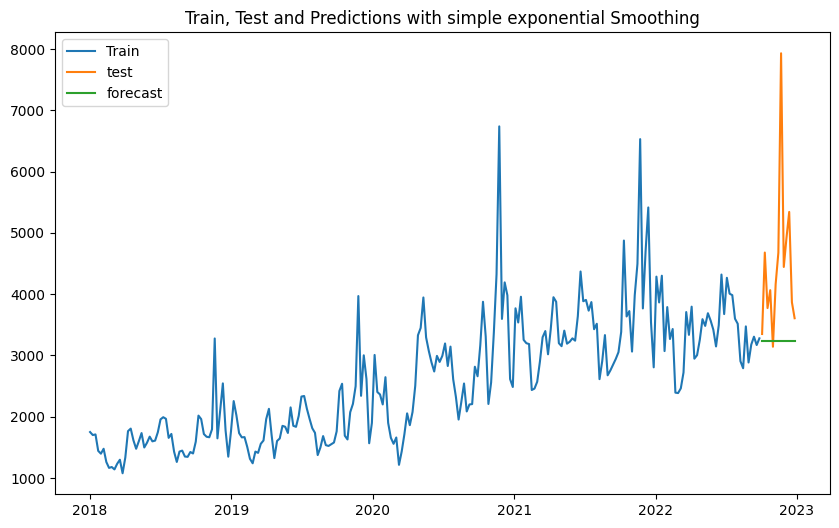

In [22]:
# Plot training ,tests and forecast
plt.figure(figsize=(10,6))
plt.plot(train , label='Train')
plt.plot(test , label='test')
plt.plot(prediction_simple , label='forecast')
plt.title("Train, Test and Predictions with simple exponential Smoothing")
plt.legend()
plt.show()

#### Double Exponential Smoothing 

In [23]:
# Double Exponential Smoothing model
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_double = ExponentialSmoothing(train, trend='additive', seasonal=None).fit()

In [24]:
prediction_double = model_double.forecast(len(test))
prediction_double

2022-10-03    3248.188426
2022-10-10    3254.078922
2022-10-17    3259.969417
2022-10-24    3265.859912
2022-10-31    3271.750408
2022-11-07    3277.640903
2022-11-14    3283.531399
2022-11-21    3289.421894
2022-11-28    3295.312389
2022-12-05    3301.202885
2022-12-12    3307.093380
2022-12-19    3312.983876
2022-12-26    3318.874371
Freq: W-MON, dtype: float64

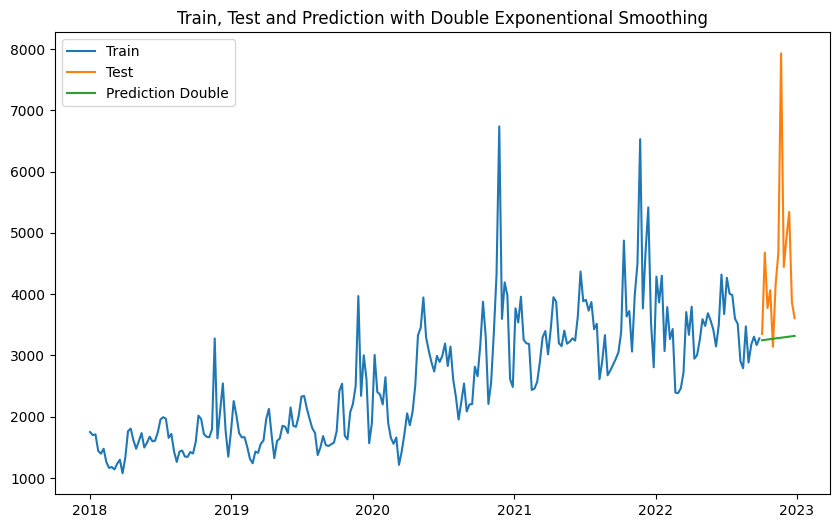

In [25]:
plt.figure(figsize=(10,6))
plt.plot(train, label='Train')
plt.plot(test, label="Test")
plt.plot(prediction_double, label="Prediction Double")
plt.legend()
plt.title("Train, Test and Prediction with Double Exponentional Smoothing")
plt.show()

#### Triple Exponential Smoothing AKA Holt-Winters

In [26]:
## Holt-Winters Method = > Level(ALPHA), Trend(BETA) & Seasonality(GAMMA)
## Holt-Winders is highly effective in forecasting with recurring patterns

# Triple Exponential Smoothing
model_triple = ExponentialSmoothing(train, trend='add', seasonal="mul",seasonal_periods=52).fit()

In [27]:
predictions_triple = model_triple.forecast(len(test))
predictions_triple

2022-10-03    4041.111424
2022-10-10    5040.624784
2022-10-17    3931.859447
2022-10-24    3531.087941
2022-10-31    3441.012595
2022-11-07    4260.019517
2022-11-14    5352.531269
2022-11-21    7237.950721
2022-11-28    4358.900107
2022-12-05    5316.382668
2022-12-12    5271.229643
2022-12-19    3471.734921
2022-12-26    3336.466558
Freq: W-MON, dtype: float64

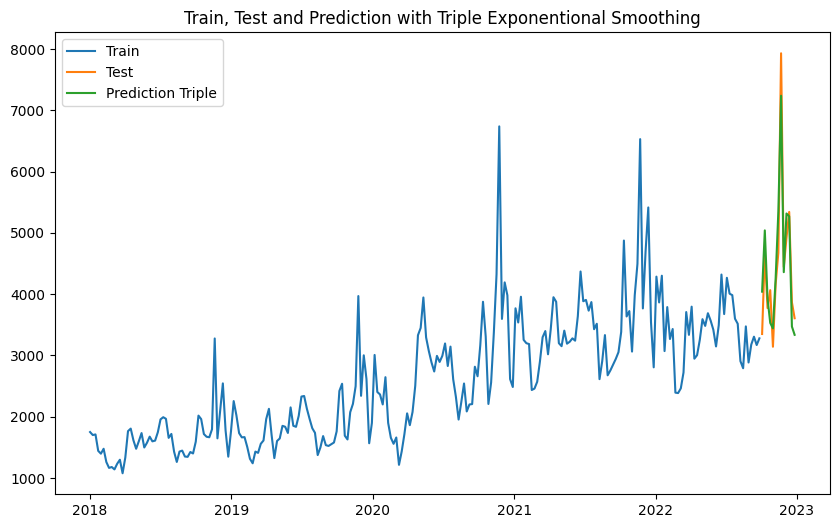

In [28]:
plt.figure(figsize=(10,6))
plt.plot(train, label='Train')
plt.plot(test, label="Test")
plt.plot(predictions_triple, label="Prediction Triple")
plt.legend()
plt.title("Train, Test and Prediction with Triple Exponentional Smoothing")
plt.show()

#### Measuring Errors
MAE is the mean of absolute differences between actual and predicted values.
RSME is the root mean of absolute differences between actual and predicted values.
MAPE : Average error in percent format.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [ ]:
# Calculating the MAE, RMSE and MAPE
mae = mean_absolute_error(test,predictions_triple)
mse = mean_squared_error(test,predictions_triple)
rmse = np.sqrt(mse)  #convert MSE -> RMSE
mape = mean_absolute_percentage_error(test,predictions_triple)
print(f"The MAE is {mae: .2f}")
print(f"The RMSE is {rmse: .2f}")
print(f"The MAPE is {100 * mape:.2f} %")

The MAE is  363.71
The RMSE is  425.49
The MAPE is 8.44 %


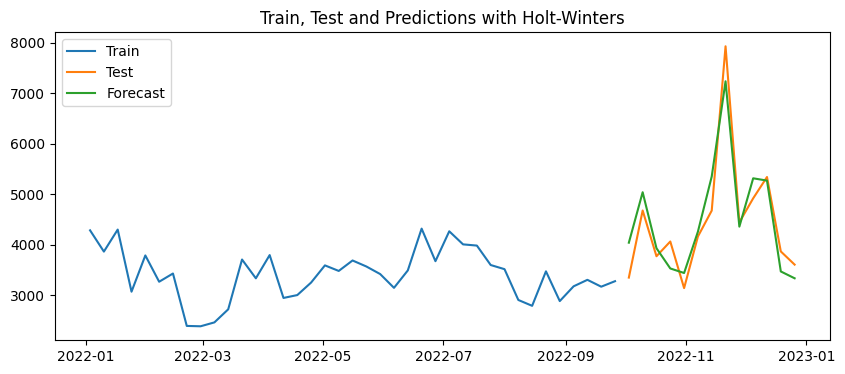

The MAE is  363.71
The RMSE is  425.49
The MAPE is 8.44 %


In [54]:
# function to assess model and visual output
def model_assessment(train, test, predictions, chart_title):
    # plot training, test and forecasts
    plt.figure(figsize=(10,4))
    plt.plot(train, label='Train')
    plt.plot(test,label="Test")
    plt.plot(predictions, label = "Forecast")
    plt.legend()
    plt.title(f"Train, Test and Predictions with {chart_title}")
    plt.show()

    mae = mean_absolute_error(test,predictions_triple)
    mse = mean_squared_error(test,predictions_triple)
    rmse = np.sqrt(mse)  #convert MSE -> RMSE
    mape = mean_absolute_percentage_error(test,predictions_triple)
    print(f"The MAE is {mae: .2f}")
    print(f"The RMSE is {rmse: .2f}")
    print(f"The MAPE is {100 * mape:.2f} %")

model_assessment(train['2022':],test,predictions_triple,'Holt-Winters')

#### Predicting the Future

In [60]:
# Triple Exponential Smoothing Model
# To predict the future you include the whole data as training data
# here we are trying to train entire df['complaints] data only 
model = ExponentialSmoothing(df.complaints, trend='add',seasonal='mul',seasonal_periods=52).fit()

In [57]:
# predictions
forecast = model.forecast(13)
forecast

2023-01-02    4965.823628
2023-01-09    4478.079585
2023-01-16    4699.503400
2023-01-23    3814.113865
2023-01-30    4242.016324
2023-02-06    3726.289103
2023-02-13    3385.536420
2023-02-20    2879.470405
2023-02-27    2978.595984
2023-03-06    3044.215856
2023-03-13    3430.500524
2023-03-20    3923.832723
2023-03-27    3794.570270
Freq: W-MON, dtype: float64

In [61]:
# Function to plot the Future
def plot_future(y, forecast, title):
    plt.figure(figsize=(10,6))
    plt.plot(y, label='Train')
    plt.plot(forecast, label="Test")
    plt.legend()
    plt.title(f"Train and Forecast with {title}")
    plt.show()

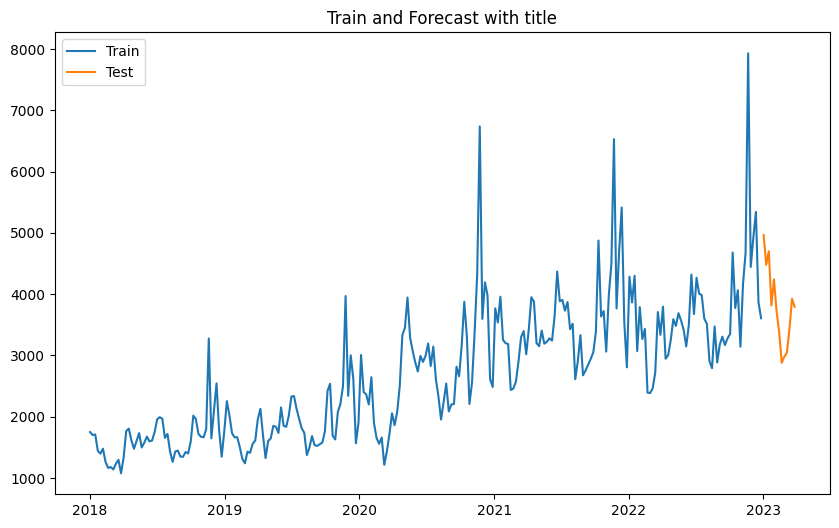

In [59]:
plot_future(df.complaints, forecast,"title")

#### Daily Data

In [62]:
df_Daily = pd.read_csv(r"C:\Users\manoj.c\Documents\PANDAS_PROJECT\Pandas-Project-6\Datasets\bitcoin_price.csv", index_col="Date", parse_dates = True)
df_Daily.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [ ]:
df_Daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3392 entries, 2014-09-17 to 2023-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3392 non-null   float64
 1   High       3392 non-null   float64
 2   Low        3392 non-null   float64
 3   Close      3392 non-null   float64
 4   Adj Close  3392 non-null   float64
 5   Volume     3392 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 185.5 KB


In [66]:
df_Daily.index
df_Daily =df_Daily.asfreq("D")
df_Daily.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq='D')

In [88]:
# Training and Test Split
periods = 30
train, test = df_Daily.iloc[:-periods,3],df_Daily.iloc[-periods:,3]
test.head()

Date
2023-12-01    38688.750000
2023-12-02    39476.332031
2023-12-03    39978.390625
2023-12-04    41980.097656
2023-12-05    44080.648438
Freq: D, Name: Close, dtype: float64

In [89]:
df_Daily.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq='D')

In [90]:
model_triple = ExponentialSmoothing(train, trend='mul',seasonal='mul',seasonal_periods=7).fit()

In [91]:
predictions_triple = model_triple.forecast(len(test))
predictions_triple

2023-12-01    37766.436799
2023-12-02    37812.703579
2023-12-03    37831.791556
2023-12-04    37825.418786
2023-12-05    37797.890069
2023-12-06    37868.350182
2023-12-07    37661.709202
2023-12-08    37715.327249
2023-12-09    37761.531416
2023-12-10    37780.593561
2023-12-11    37774.229415
2023-12-12    37746.737953
2023-12-13    37817.102711
2023-12-14    37610.741380
2023-12-15    37664.286865
2023-12-16    37710.428504
2023-12-17    37729.464852
2023-12-18    37723.109319
2023-12-19    37695.655061
2023-12-20    37765.924594
2023-12-21    37559.842533
2023-12-22    37613.315555
2023-12-23    37659.394750
2023-12-24    37678.405336
2023-12-25    37672.058404
2023-12-26    37644.641300
2023-12-27    37714.815737
2023-12-28    37509.012568
2023-12-29    37562.413224
2023-12-30    37608.430060
Freq: D, dtype: float64

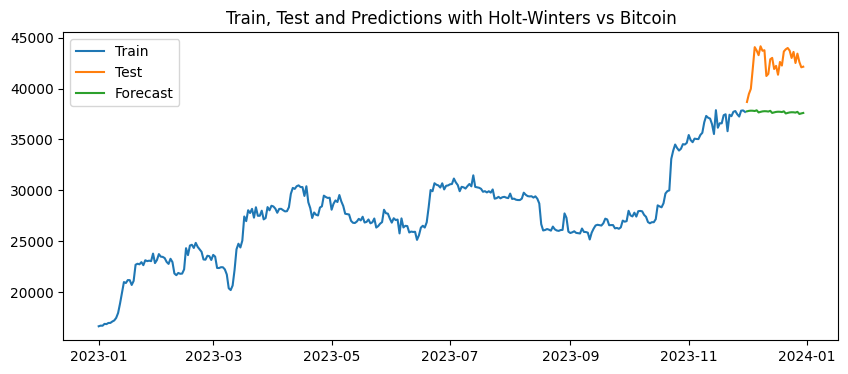

The MAE is  4846.89
The RMSE is  5040.19
The MAPE is 11.29 %


In [92]:
# Model Assessment
model_assessment(train['2023':], test, predictions_triple,"Holt-Winters vs Bitcoin")

In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(test, predictions_triple)
rmse = np.sqrt(mean_squared_error(test, predictions_triple))
mape = mean_absolute_percentage_error(test, predictions_triple)

print(mae, rmse, mape)


4846.891639824416 5040.19370565024 0.11293658168243471


#### Holt-Winter is popular for forecasting time series data with trends and seasonality
##### Pros: Simple Implementation, Intuitive Model & Adaptable to Changes
##### Cons: Only one seasonal component, No room for regressors